In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### FUNCTIONS ###

def generate_points(mean=[0., 0.], angle_deg=45, lamb=np.array([[100, 0], [0, 1]]), n=100, seed=None):
    """
    Generate random 2D points with covariance structure defined by rotation and lambda matrix.
    """
    if seed is not None:
        np.random.seed(seed)

    angle = angle_deg * math.pi / 180
    rot = np.array([[math.cos(angle), -math.sin(angle)], 
                    [math.sin(angle),  math.cos(angle)]])
    s = np.matmul(rot, np.matmul(lamb, rot.T))
    points = np.random.multivariate_normal(mean, s, n)
    return points


def plot_regression(points, w, outliers=None, title="Linear Regression Fit"):
    """
    Plot dataset and regression line.
    
    points: Nx2 array of [x, y]
    w: tuple/list (w0, w1)
    outliers: list of indices to highlight
    """
    x = points[:, 0]
    y = points[:, 1]
    y_pred = w[0] * x + w[1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, label='Data points', color='blue', alpha=0.7)

    # Highlight outliers if any
    if outliers is not None:
        plt.scatter(x[outliers], y[outliers], color='red', label='Outliers', s=80, marker='x')

    plt.plot(x, y_pred, color='orange', linewidth=2, label='Fitted line')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()


def gradient_descent(points, rho=lambda u: 0.5 * u**2, rho_prime=lambda u: u, 
                     alpha=1e-4, max_iter=10000, tol=1e-6, return_residuals=False):
    """
    Perform gradient descent to find w0, w1 minimizing sum of rho(e_i)
    where e_i = w0*x_i + w1 - y_i.

    Parameters:
    - rho, rho_prime: error function and its derivative
    - alpha: learning rate
    - tol: stopping threshold for gradient norm
    - return_residuals: if True, returns (w0, w1, residuals)
    """
    x = points[:, 0]
    y = points[:, 1]

    # Initialize parameters
    w0, w1 = 0.0, 0.0

    for i in range(max_iter):
        y_pred = w0 * x + w1
        e = y_pred - y

        # Compute gradients
        grad_w0 = np.sum(rho_prime(e) * x)
        grad_w1 = np.sum(rho_prime(e))

        grad_norm = np.sqrt(grad_w0**2 + grad_w1**2)
        if grad_norm < tol:
            break

        # Update parameters
        w0 -= alpha * grad_w0
        w1 -= alpha * grad_w1

    if return_residuals:
        return w0, w1, rho(e)  # include residuals
    else:
        return w0, w1


def gradient_descent_robust(points, c=1, alpha=1e-4, max_iter=10000, tol=1e-6, return_residuals=False):
    """
    Perform gradient descent using the Cauchy robust error function:
    rho(u) = (c^2 / 2) * log(1 + (u / c)^2)
    rho'(u) = u / (1 + (u / c)^2)
    """
    rho = lambda u: 0.5 * (c**2) * np.log(1 + (u / c)**2)
    rho_prime = lambda u: u / (1 + (u / c)**2)

    return gradient_descent(points, rho=rho, rho_prime=rho_prime,
                            alpha=alpha, max_iter=max_iter, tol=tol,
                            return_residuals=return_residuals)


def compare_regression_methods(points, c=1, title_suffix="(no outliers)"):
    """
    Compare Least Squares vs Cauchy Robust regression on the same dataset.
    Fits both models, prints parameters, and plots results.
    """
    # Fit both models
    w_ls = gradient_descent(points)
    w_cauchy = gradient_descent_robust(points, c=c)

    # Print parameters
    print(f"=== Regression Comparison {title_suffix} ===")
    print(f"Least Squares Fit: w0 = {w_ls[0]:.4f}, w1 = {w_ls[1]:.4f}")
    print(f"Cauchy Robust Fit (c={c}): w0 = {w_cauchy[0]:.4f}, w1 = {w_cauchy[1]:.4f}")

    # Plot comparison
    x = points[:, 0]
    y = points[:, 1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')

    # Compute predicted lines
    y_ls = w_ls[0] * x + w_ls[1]
    y_cauchy = w_cauchy[0] * x + w_cauchy[1]

    # Plot both
    plt.plot(x, y_ls, color='orange', linewidth=2, label='Least Squares Fit')
    plt.plot(x, y_cauchy, color='green', linewidth=2, linestyle='--', label=f'Cauchy Robust Fit (c={c})')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Linear Regression Comparison {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.show()

    return w_ls, w_cauchy


Least Squares Fit Parameters:
w0 (slope): 0.9659664355531029
w1 (intercept): 0.07510702192147199


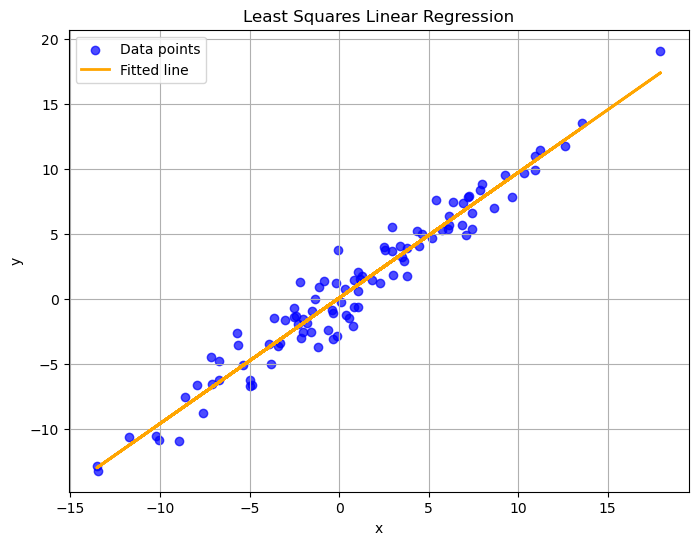

In [2]:
# Generate points
points = generate_points(angle_deg=45, seed=42)

# Least squares regression (rho(u) = 0.5*u^2)
w_ls = gradient_descent(points)

print("Least Squares Fit Parameters:")
print("w0 (slope):", w_ls[0])
print("w1 (intercept):", w_ls[1])

# Plot result
plot_regression(points, w_ls, title="Least Squares Linear Regression")

Least Squares Fit Parameters:
w0 (slope): 0.5222779250220864
w1 (intercept): 0.8541772108284581


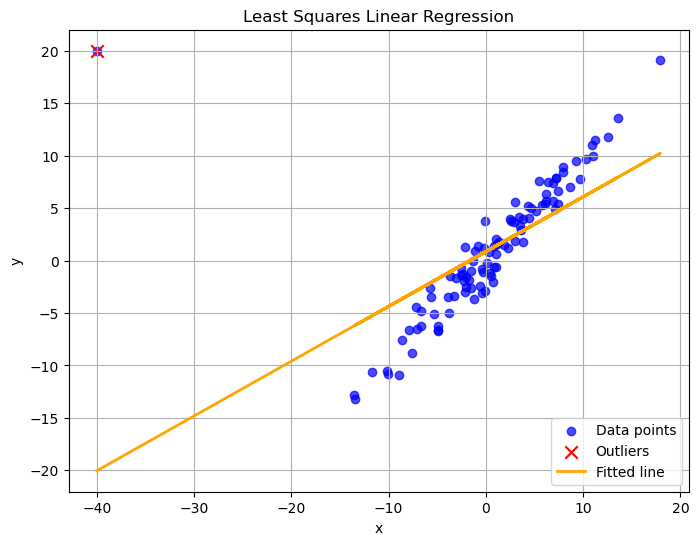

In [3]:
out_idx = 0
points[out_idx] = [-40, 20]
outliers = [out_idx]

# Least squares regression (rho(u) = 0.5*u^2)
w_ls = gradient_descent(points)

print("Least Squares Fit Parameters:")
print("w0 (slope):", w_ls[0])
print("w1 (intercept):", w_ls[1])

# Plot result
plot_regression(points, w_ls, title="Least Squares Linear Regression", outliers=outliers)

Let  

$$
e_i = \hat{y}_i - y_i = w_0 x_i + w_1 - y_i, \qquad 
Q(w) = \sum_{i=1}^m \rho(e_i).
$$

When we have a general error function $\rho$, by the chain rule,  

$$
\frac{\partial Q}{\partial w_0} = \sum_{i=1}^m \rho'(e_i) \frac{\partial e_i}{\partial w_0}
= \sum_{i=1}^m \rho'(e_i)\,x_i,
$$

$$
\frac{\partial Q}{\partial w_1} = \sum_{i=1}^m \rho'(e_i) \frac{\partial e_i}{\partial w_1}
= \sum_{i=1}^m \rho'(e_i).
$$

So compactly, the gradient is  

$$
\nabla Q(w) =
\begin{pmatrix}
\sum_i \rho'(e_i)\,x_i \\[4pt]
\sum_i \rho'(e_i)
\end{pmatrix}.
$$

We apply this to use $\rho(u)=\frac{c^{2}}{2}\log\!\Big(1+\big(\tfrac{u}{c}\big)^{2}\Big)$ as our loss function

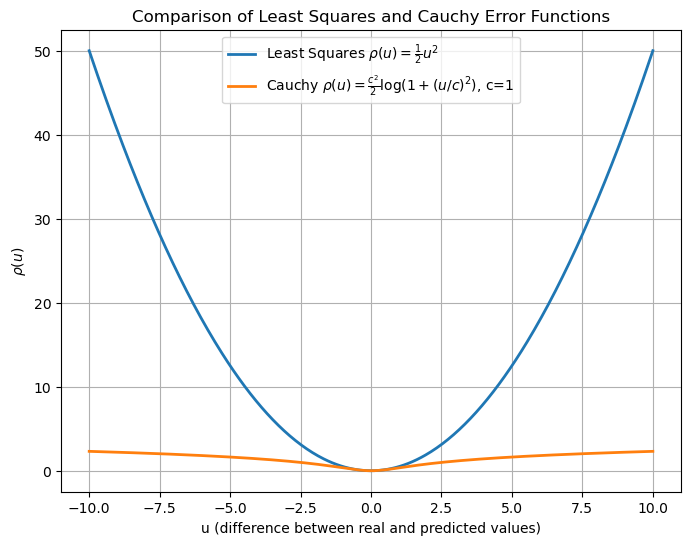

In [5]:
# Compare Least Squares vs Cauchy function
u = np.linspace(-10, 10, 400)
rho_ls = 0.5 * u**2
c = 1
rho_cauchy = 0.5 * (c**2) * np.log(1 + (u / c)**2)

plt.figure(figsize=(8, 6))
plt.plot(u, rho_ls, label=r'Least Squares $\rho(u) = \frac{1}{2}u^2$', linewidth=2)
plt.plot(u, rho_cauchy, label=r'Cauchy $\rho(u) = \frac{c^2}{2}\log(1+(u/c)^2)$, c=1', linewidth=2)
plt.xlabel('u (difference between real and predicted values)')
plt.ylabel(r'$\rho(u)$')
plt.title('Comparison of Least Squares and Cauchy Error Functions')
plt.legend()
plt.grid(True)
plt.show()

=== Regression Comparison (clean dataset) ===
Least Squares Fit: w0 = 0.9851, w1 = 0.2005
Cauchy Robust Fit (c=1): w0 = 0.9856, w1 = 0.2519


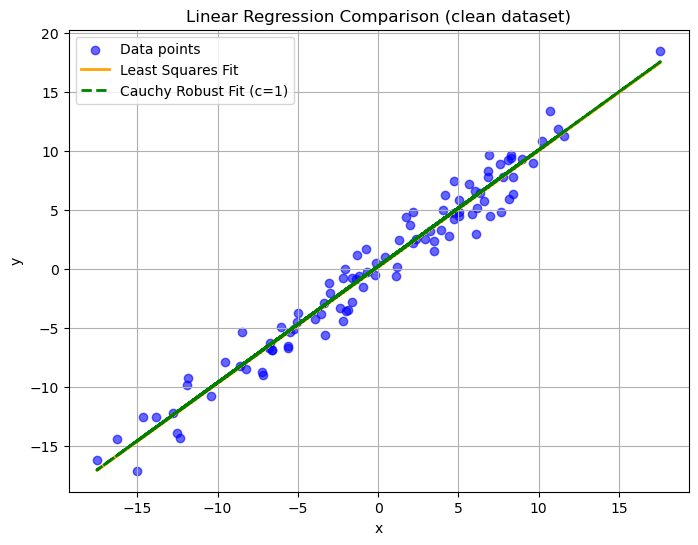

In [6]:
# Generate new clean dataset
points = generate_points(angle_deg=45, seed=0)


# Compare Least Squares and Cauchy Robust regression
w_ls, w_cauchy = compare_regression_methods(points, c=1, title_suffix="(clean dataset)")

We can see that the predictions are very similar. The lines are barely recognisable in the image.

=== Regression Comparison (clean dataset) ===
Least Squares Fit: w0 = 0.6338, w1 = 0.6620
Cauchy Robust Fit (c=1): w0 = 0.9873, w1 = 0.2453


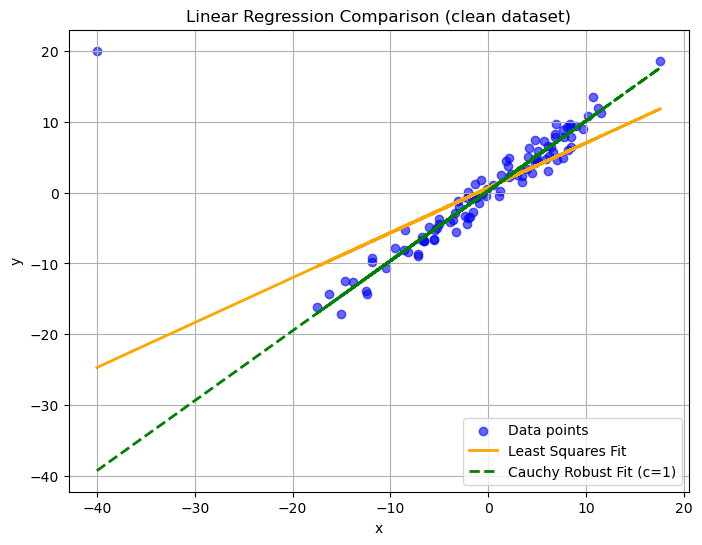

In [8]:
# Generate new clean dataset and perturbate it
points = generate_points(angle_deg=45, seed=0)
out_idx = 0
points[out_idx] = [-40, 20]
outliers = [out_idx]

# Compare Least Squares and Cauchy Robust regression
w_ls, w_cauchy = compare_regression_methods(points, c=1, title_suffix="(clean dataset)")

With one outlier, as we can see in the plot, the line generated by the Cauchy error function is very close to the previous line, but the line generated by Least Squares is strongly modified. The prediction of the Cauchy method seems much more reasonable in this case. 

Least Squares: w0 = 0.6338048698823504 w1 = 0.6620055963742805


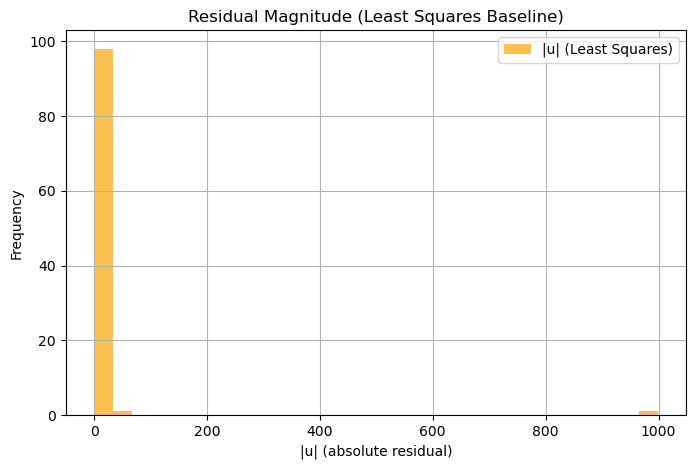

Cauchy Robust (c=1): w0 = 0.9872955438750042, w1 = 0.24528152558361713


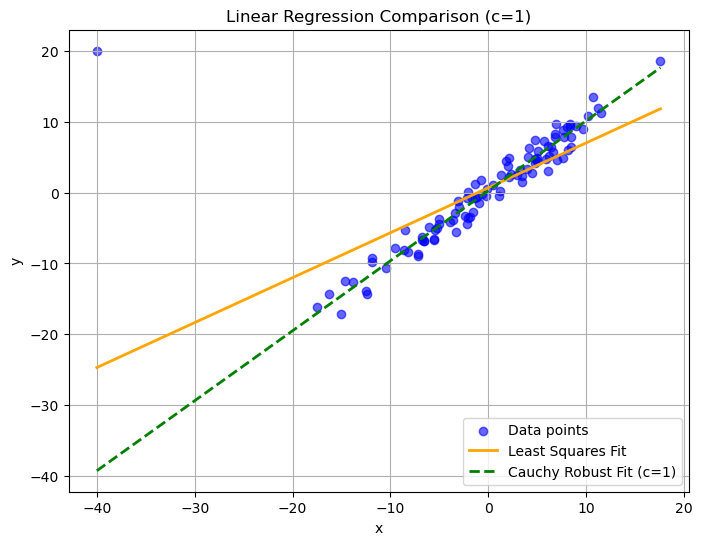

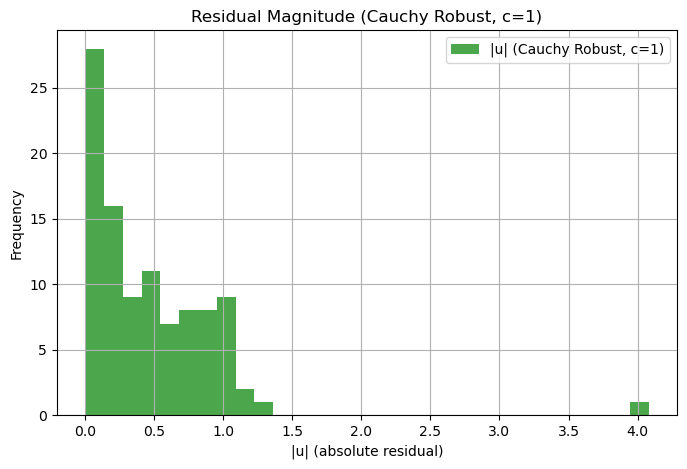

Cauchy Robust (c=100): w0 = 0.6830952584784605, w1 = 0.5972675080762283


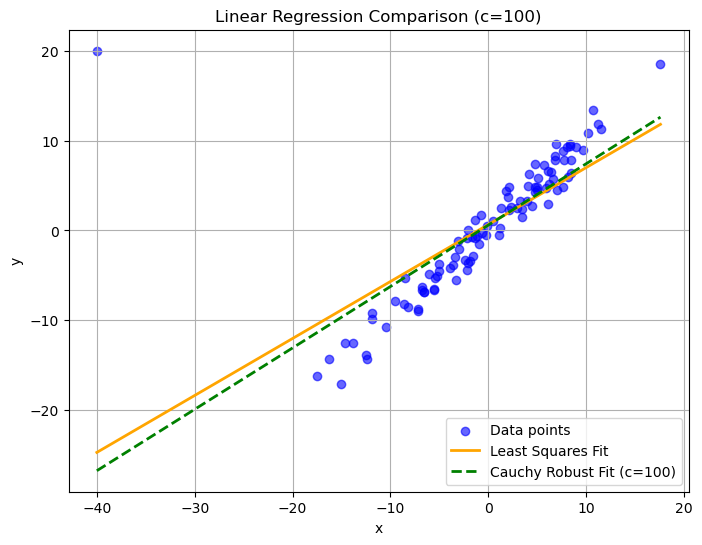

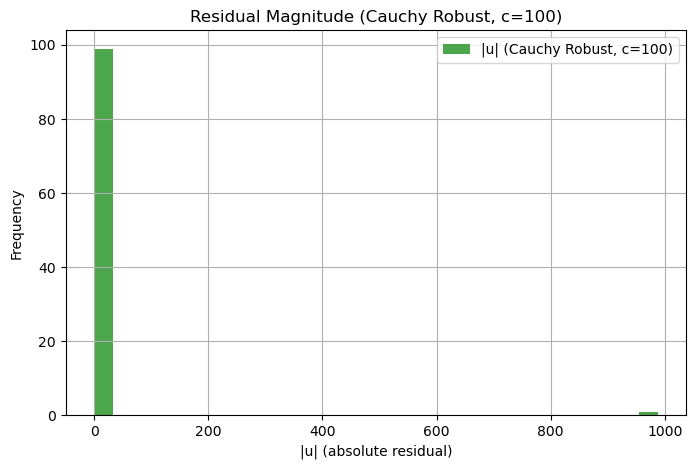

Cauchy Robust (c=0.01): w0 = 0.0002663933529023827, w1 = 0.004465373627183461


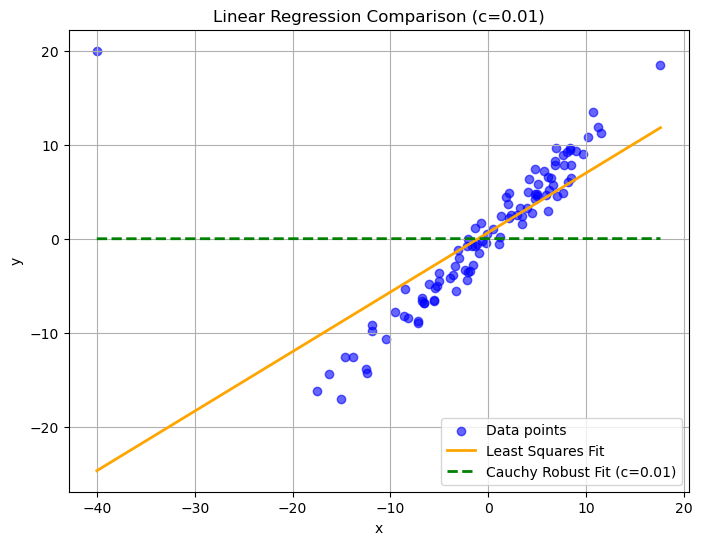

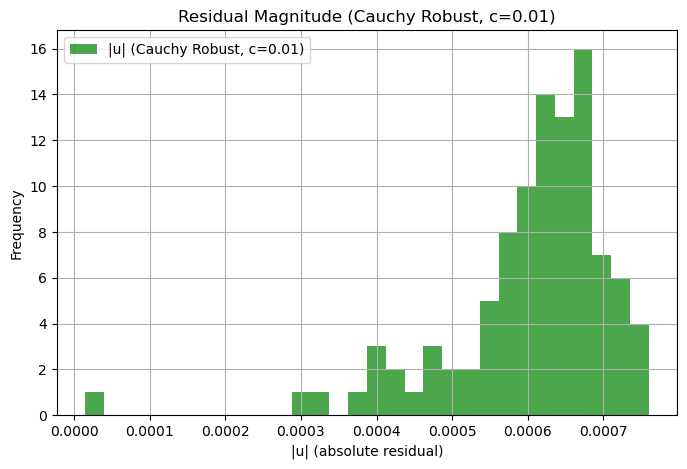

Cauchy Robust (c=0.001): w0 = -0.00011072281570225057, w1 = 9.990916911993612e-05


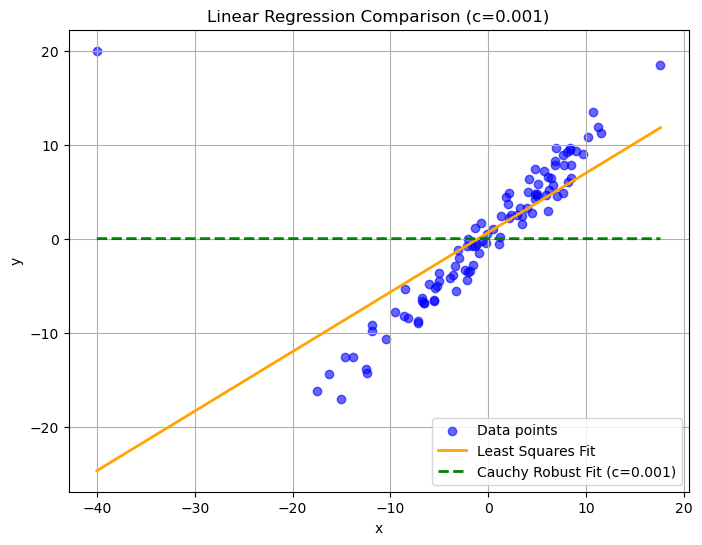

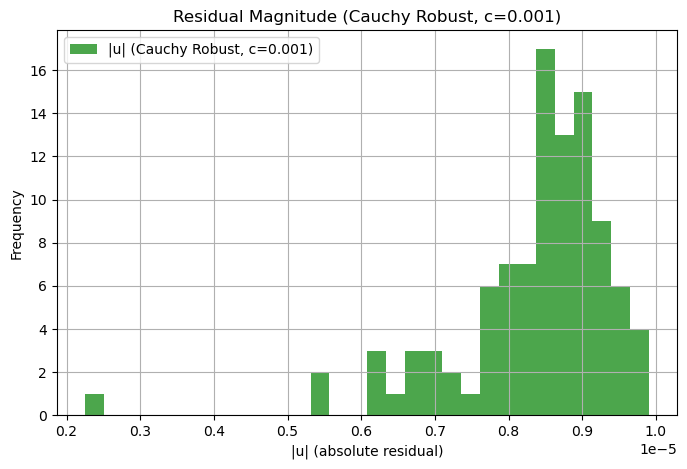

In [10]:
## EX 5 ##

# Generate new dataset and introduce one outlier
points = generate_points(angle_deg=45, seed=0)
points[0] = [-40, 20]  # strong outlier

# Compute least squares baseline
w_ls, w1, u_ls = gradient_descent(points, return_residuals=True)
print("Least Squares: w0 =", w_ls, "w1 =", w1)

# --- Plot Least Squares histogram once (baseline) ---
plt.figure(figsize=(8, 5))
plt.hist(np.abs(u_ls), bins=30, alpha=0.7, color='orange', label='|u| (Least Squares)')
plt.xlabel('|u| (absolute residual)')
plt.ylabel('Frequency')
plt.title('Residual Magnitude (Least Squares Baseline)')
plt.legend()
plt.grid(True)
plt.show()

# Try several Cauchy parameter values
c_values = [1, 100, 1/100, 1/1000]

for c in c_values:    
    # Compute robust regression and residuals
    w_c, w2, u_cauchy = gradient_descent_robust(points, c=c, return_residuals=True)
    print(f"Cauchy Robust (c={c}): w0 = {w_c}, w1 = {w2}")

    # --- Plot regression lines comparison ---
    x = points[:, 0]
    y = points[:, 1]
    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]

    y_ls = w_ls * x_sorted + w1
    y_cauchy = w_c * x_sorted + w2

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')
    plt.plot(x_sorted, y_ls, color='orange', linewidth=2, label='Least Squares Fit')
    plt.plot(x_sorted, y_cauchy, color='green', linewidth=2, linestyle='--', label=f'Cauchy Robust Fit (c={c})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Linear Regression Comparison (c={c})')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot residual magnitude histogram for Cauchy ---
    plt.figure(figsize=(8, 5))
    plt.hist(np.abs(u_cauchy), bins=30, alpha=0.7, color='green', label=f'|u| (Cauchy Robust, c={c})')
    plt.xlabel('|u| (absolute residual)')
    plt.ylabel('Frequency')
    plt.title(f'Residual Magnitude (Cauchy Robust, c={c})')
    plt.legend()
    plt.grid(True)
    plt.show()


Baseline (clean data) Least Squares: w0=0.985088, w1=0.200515

Cauchy parameter c = 1
Outliers =  5 | LS: w0=-0.048264, w1=2.422356, RMSE_all=11.5086, RMSE_inliers=7.7250
                 Cauchy(c=1): w0=0.976075, w1=0.266849, RMSE_all=15.5795, RMSE_inliers=1.4308
Outliers = 10 | LS: w0=-0.184857, w1=6.972475, RMSE_all=22.2965, RMSE_inliers=10.4593
                 Cauchy(c=1): w0=0.966501, w1=0.311112, RMSE_all=26.2646, RMSE_inliers=1.4539


C:\Users\carlo\AppData\Local\Temp\ipykernel_5900\3439507028.py:76: RuntimeWarning: overflow encountered in scalar power
  grad_norm = np.sqrt(grad_w0**2 + grad_w1**2)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\carlo\AppData\Local\Temp\ipykernel_5900\3439507028.py:69: RuntimeWarning: invalid value encountered in multiply
  y_pred = w0 * x + w1
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Outliers = 20 | LS: w0=nan, w1=nan, RMSE_all=nan, RMSE_inliers=nan
                 Cauchy(c=1): w0=0.967321, w1=0.336609, RMSE_all=49.8626, RMSE_inliers=1.4424


C:\Users\carlo\AppData\Local\Temp\ipykernel_5900\3439507028.py:73: RuntimeWarning: overflow encountered in multiply
  grad_w0 = np.sum(rho_prime(e) * x)


Outliers = 40 | LS: w0=nan, w1=nan, RMSE_all=nan, RMSE_inliers=nan
                 Cauchy(c=1): w0=0.988226, w1=0.665308, RMSE_all=106.2516, RMSE_inliers=1.5057


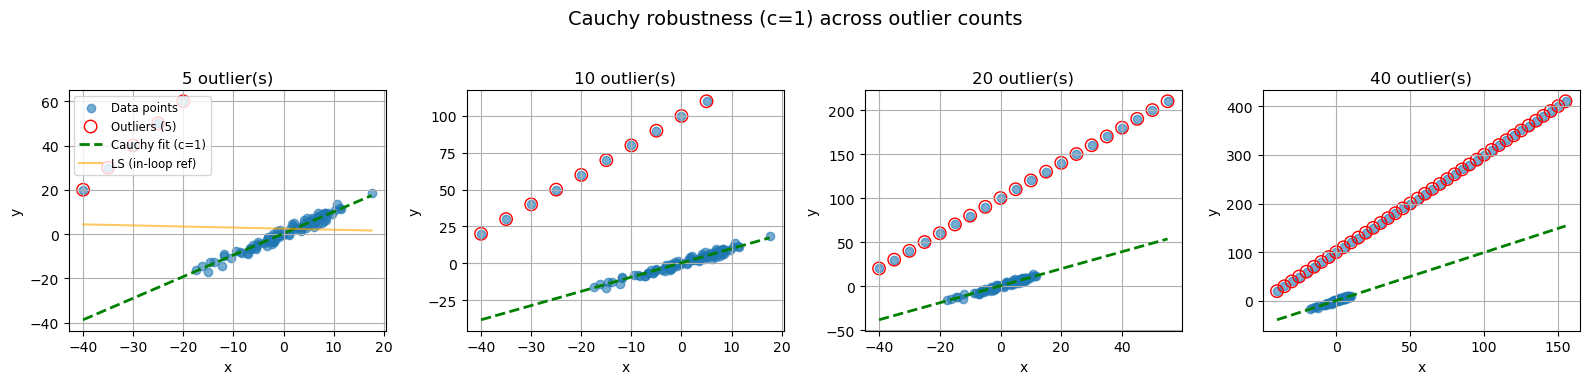

Cauchy parameter c = 0.01
Outliers =  5 | LS: w0=-0.048264, w1=2.422356, RMSE_all=11.5086, RMSE_inliers=7.7250
                 Cauchy(c=0.01): w0=-0.000145, w1=0.004291, RMSE_all=11.7811, RMSE_inliers=7.1692
Outliers = 10 | LS: w0=-0.184857, w1=6.972475, RMSE_all=22.2965, RMSE_inliers=10.4593
                 Cauchy(c=0.01): w0=0.008970, w1=-0.000234, RMSE_all=23.5099, RMSE_inliers=7.1808
Outliers = 20 | LS: w0=nan, w1=nan, RMSE_all=nan, RMSE_inliers=nan
                 Cauchy(c=0.01): w0=0.008063, w1=0.000054, RMSE_all=57.7906, RMSE_inliers=6.8820
Outliers = 40 | LS: w0=nan, w1=nan, RMSE_all=nan, RMSE_inliers=nan
                 Cauchy(c=0.01): w0=0.006598, w1=0.000101, RMSE_all=154.1065, RMSE_inliers=6.9687


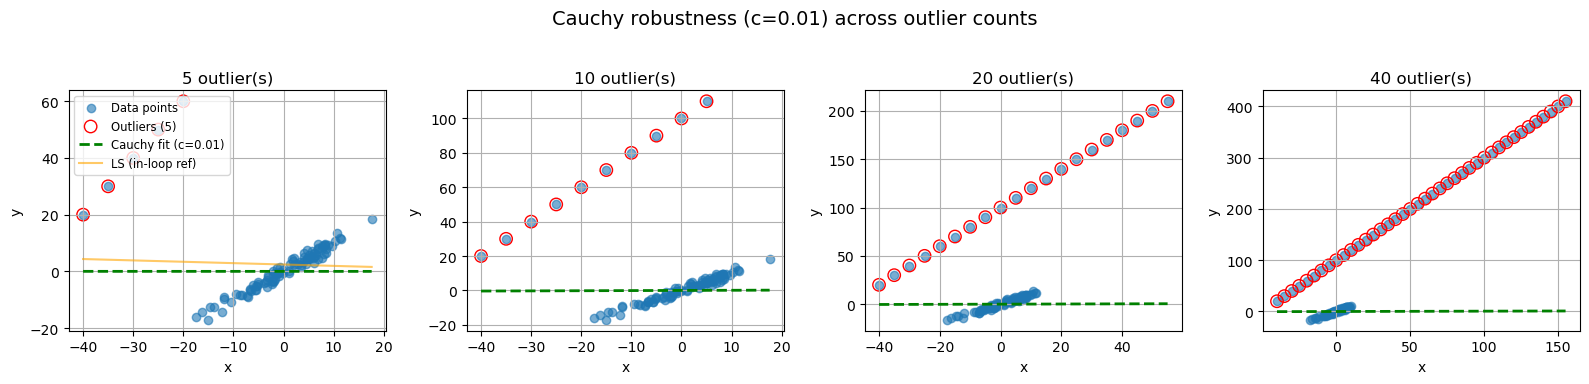


Experiment finished.


In [11]:
###  EX 6 TYPE OF NOISE 1 ###

import numpy as np
import matplotlib.pyplot as plt

def run_cauchy_outlier_experiment(
    outlier_counts=(5,10,20, 40), 
    c_values=(1, 1/100),
    n_points_display=50,
    outlier_offset_x=-40,
    outlier_offset_y=20,
    outlier_spacing=(5, 10)
):
    """
    For each c in c_values and each number of outliers in outlier_counts:
      - generate a fresh dataset (same seed for reproducibility)
      - replace the first n_outliers points with strong outliers
      - fit least-squares (baseline) and cauchy robust
      - plot fits and mark outliers
      - print w estimates and RMSE (all / inliers)
    """
    # helper to compute RMSE
    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))

    # first compute LS baseline once on the original dataset with ONE outlier (or none) if you prefer:
    base_points = generate_points(angle_deg=45, seed=0)  # original clean dataset

    # We'll print a baseline LS fit on clean data (no outliers) for reference:
    w_ls_clean, b_ls_clean = gradient_descent(base_points, return_residuals=False)
    print("Baseline (clean data) Least Squares:", f"w0={w_ls_clean:.6f}, w1={b_ls_clean:.6f}\n")

    # Loop over c values
    for c in c_values:
        print("===============================")
        print(f"Cauchy parameter c = {c}")
        print("===============================")

        # Prepare a 2x(len(outlier_counts)) grid: left column fit plots, right column histograms optionally
        n_cases = len(outlier_counts)
        fig, axes = plt.subplots(1, n_cases, figsize=(4*n_cases, 4), squeeze=False)
        # We'll use a single row of subplots: each column shows data with Cauchy fit and marks outliers.
        for idx, n_outliers in enumerate(outlier_counts):
            # regenerate clean dataset for each case to keep comparisons fair
            points = generate_points(angle_deg=45, seed=0).copy()

            # specify outliers by overwriting the first n_outliers points
            for j in range(min(n_outliers, len(points))):
                dx = outlier_offset_x + j * outlier_spacing[0]
                dy = outlier_offset_y + j * outlier_spacing[1]
                points[j, 0] = dx
                points[j, 1] = dy

            # indices of outliers
            outlier_idx = np.arange(min(n_outliers, len(points)))

            # Fit LS and Cauchy robust
            w_ls, b_ls, u_ls = gradient_descent(points, return_residuals=True)
            w_c, b_c, u_c = gradient_descent_robust(points, c=c, return_residuals=True)

            # compute predictions and RMSEs
            x = points[:, 0]
            y = points[:, 1]
            ypred_ls = w_ls * x + b_ls
            ypred_c = w_c * x + b_c

            rmse_all_ls = rmse(y, ypred_ls)
            rmse_all_c = rmse(y, ypred_c)

            # RMSE on inliers (exclude first n_outliers)
            if n_outliers < len(points):
                inlier_idx = np.arange(n_outliers, len(points))
                rmse_inliers_ls = rmse(y[inlier_idx], ypred_ls[inlier_idx])
                rmse_inliers_c = rmse(y[inlier_idx], ypred_c[inlier_idx])
            else:
                rmse_inliers_ls = np.nan
                rmse_inliers_c = np.nan

            # Print summary numbers
            print(f"Outliers = {n_outliers:2d} | LS: w0={w_ls:.6f}, w1={b_ls:.6f}, RMSE_all={rmse_all_ls:.4f}, RMSE_inliers={rmse_inliers_ls:.4f}")
            print(f"                 Cauchy(c={c}): w0={w_c:.6f}, w1={b_c:.6f}, RMSE_all={rmse_all_c:.4f}, RMSE_inliers={rmse_inliers_c:.4f}")

            # Plot: data points, outliers highlighted, and the Cauchy fit only (no LS comparison in-loop)
            ax = axes[0, idx]
            ax.scatter(x, y, color='tab:blue', alpha=0.6, label='Data points')
            if n_outliers > 0:
                ax.scatter(points[outlier_idx, 0], points[outlier_idx, 1], 
                           facecolors='none', edgecolors='red', s=80, label=f'Outliers ({n_outliers})')

            # plot Cauchy line (sorted for a smooth line)
            sort_idx = np.argsort(x)
            x_sorted = x[sort_idx]
            ax.plot(x_sorted, w_c * x_sorted + b_c, color='green', linewidth=2, linestyle='--', label=f'Cauchy fit (c={c})')

            # optionally plot LS baseline once on first panel as reference (comment/uncomment)
            if idx == 0:
                # show baseline LS on first panel if you like (comment out to keep no-LS in loop)
                ax.plot(x_sorted, w_ls * x_sorted + b_ls, color='orange', linewidth=1.5, alpha=0.6, label='LS (in-loop ref)')
            
            ax.set_title(f"{n_outliers} outlier(s)")
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.grid(True)
            if idx == 0:
                ax.legend(loc='upper left', fontsize='small')

        plt.suptitle(f"Cauchy robustness (c={c}) across outlier counts", fontsize=14)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    print("\nExperiment finished.")

run_cauchy_outlier_experiment()


Baseline (clean data) LS: w0=0.9851, w1=0.2005

Cauchy parameter c = 1
Outliers =  5 | LS: w0=-0.0075, w1=1.4157, RMSE_inliers=7.260
                 Cauchy(c=1): w0=0.9739, w1=0.2680, RMSE_inliers=1.432


C:\Users\carlo\AppData\Local\Temp\ipykernel_5900\3439507028.py:76: RuntimeWarning: overflow encountered in scalar power
  grad_norm = np.sqrt(grad_w0**2 + grad_w1**2)
C:\Users\carlo\AppData\Local\Temp\ipykernel_5900\3439507028.py:81: RuntimeWarning: invalid value encountered in scalar subtract
  w0 -= alpha * grad_w0


Outliers = 10 | LS: w0=nan, w1=nan, RMSE_inliers=nan
                 Cauchy(c=1): w0=0.9609, w1=0.3170, RMSE_inliers=1.458
Outliers = 20 | LS: w0=nan, w1=nan, RMSE_inliers=nan
                 Cauchy(c=1): w0=0.9546, w1=0.3442, RMSE_inliers=1.451
Outliers = 30 | LS: w0=nan, w1=nan, RMSE_inliers=nan
                 Cauchy(c=1): w0=-0.1766, w1=2.3259, RMSE_inliers=8.305
Outliers = 40 | LS: w0=nan, w1=nan, RMSE_inliers=nan
                 Cauchy(c=1): w0=-0.0986, w1=1.5499, RMSE_inliers=7.815


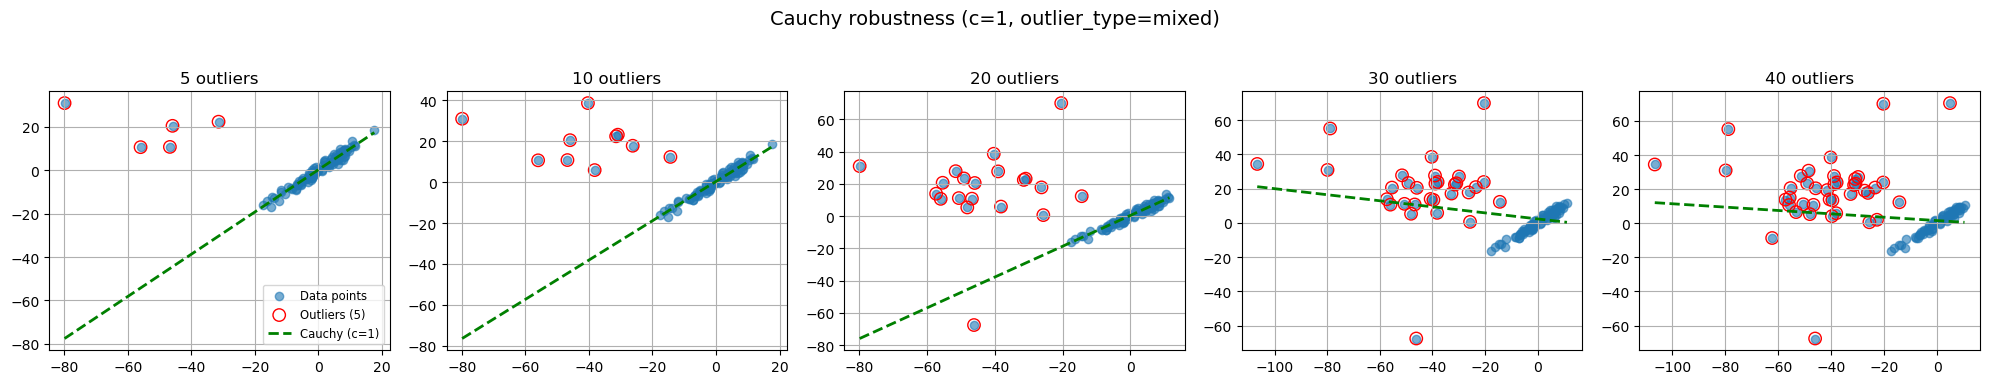

Cauchy parameter c = 0.01
Outliers =  5 | LS: w0=-0.0075, w1=1.4157, RMSE_inliers=7.260
                 Cauchy(c=0.01): w0=-0.0007, w1=0.0040, RMSE_inliers=7.173
Outliers = 10 | LS: w0=nan, w1=nan, RMSE_inliers=nan
                 Cauchy(c=0.01): w0=0.0068, w1=-0.0002, RMSE_inliers=7.196
Outliers = 20 | LS: w0=nan, w1=nan, RMSE_inliers=nan
                 Cauchy(c=0.01): w0=-0.0016, w1=0.0003, RMSE_inliers=6.947
Outliers = 30 | LS: w0=nan, w1=nan, RMSE_inliers=nan
                 Cauchy(c=0.01): w0=-0.0050, w1=0.0004, RMSE_inliers=6.932
Outliers = 40 | LS: w0=nan, w1=nan, RMSE_inliers=nan
                 Cauchy(c=0.01): w0=-0.0103, w1=0.0006, RMSE_inliers=7.084


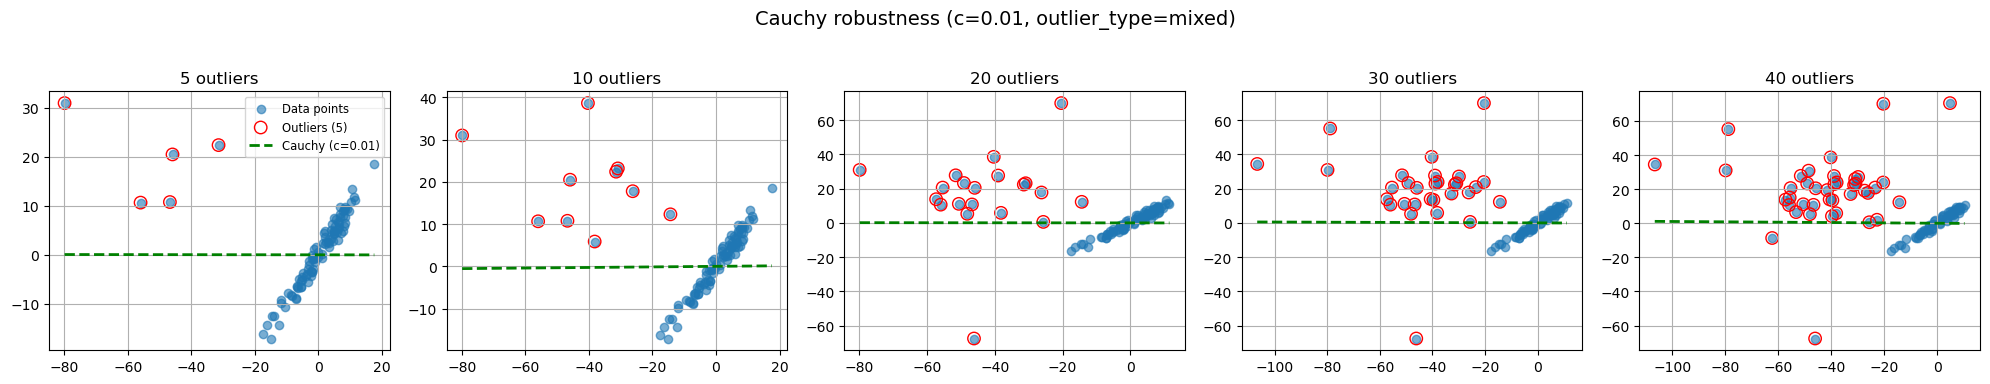


✅ Experiment finished.


In [12]:
###  EX 6 TYPE OF NOISE 2 ###

import numpy as np
import matplotlib.pyplot as plt

def run_cauchy_outlier_experiment(
    outlier_counts=(5, 10, 20, 30, 40), 
    c_values=(1, 1/100),
    outlier_type="mixed",   # "gaussian", "uniform", "laplace", "cauchy", or "mixed"
    base_angle=45,
    seed=0
):
    """
    Experiment showing robustness of Cauchy loss under different types of outlier noise.
    """

    np.random.seed(seed)

    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))

    base_points = generate_points(angle_deg=base_angle, seed=seed)
    w_ls_clean, b_ls_clean = gradient_descent(base_points, return_residuals=False)
    print(f"Baseline (clean data) LS: w0={w_ls_clean:.4f}, w1={b_ls_clean:.4f}\n")

    for c in c_values:
        print("===========================================")
        print(f"Cauchy parameter c = {c}")
        print("===========================================")

        n_cases = len(outlier_counts)
        fig, axes = plt.subplots(1, n_cases, figsize=(4 * n_cases, 4), squeeze=False)

        for idx, n_outliers in enumerate(outlier_counts):
            # regenerate clean dataset
            points = generate_points(angle_deg=base_angle, seed=seed).copy()

            # create noisy outliers depending on the chosen distribution
            n_out = min(n_outliers, len(points))
            if n_out > 0:
                if outlier_type == "gaussian":
                    noise_x = np.random.normal(-40, 10, size=n_out)
                    noise_y = np.random.normal(20, 10, size=n_out)
                elif outlier_type == "uniform":
                    noise_x = np.random.uniform(-60, -20, size=n_out)
                    noise_y = np.random.uniform(10, 50, size=n_out)
                elif outlier_type == "laplace":
                    noise_x = np.random.laplace(-40, 10, size=n_out)
                    noise_y = np.random.laplace(20, 10, size=n_out)
                elif outlier_type == "cauchy":
                    noise_x = np.random.standard_cauchy(size=n_out) * 15 - 40
                    noise_y = np.random.standard_cauchy(size=n_out) * 15 + 20
                elif outlier_type == "mixed":
                    # randomly pick a type per outlier
                    noise_x = np.zeros(n_out)
                    noise_y = np.zeros(n_out)
                    for j in range(n_out):
                        t = np.random.choice(["gaussian", "uniform", "laplace", "cauchy"])
                        if t == "gaussian":
                            noise_x[j] = np.random.normal(-40, 10)
                            noise_y[j] = np.random.normal(20, 10)
                        elif t == "uniform":
                            noise_x[j] = np.random.uniform(-60, -20)
                            noise_y[j] = np.random.uniform(10, 50)
                        elif t == "laplace":
                            noise_x[j] = np.random.laplace(-40, 10)
                            noise_y[j] = np.random.laplace(20, 10)
                        else:
                            noise_x[j] = np.random.standard_cauchy() * 15 - 40
                            noise_y[j] = np.random.standard_cauchy() * 15 + 20
                else:
                    raise ValueError(f"Unknown outlier_type: {outlier_type}")

                # apply outliers
                points[:n_out, 0] = noise_x
                points[:n_out, 1] = noise_y

            # indices of outliers
            outlier_idx = np.arange(n_out)

            # Fit both models
            w_ls, b_ls, u_ls = gradient_descent(points, return_residuals=True)
            w_c, b_c, u_c = gradient_descent_robust(points, c=c, return_residuals=True)

            # Compute metrics
            x = points[:, 0]
            y = points[:, 1]
            ypred_ls = w_ls * x + b_ls
            ypred_c = w_c * x + b_c

            rmse_all_ls = rmse(y, ypred_ls)
            rmse_all_c = rmse(y, ypred_c)

            inlier_idx = np.arange(n_out, len(points))
            if len(inlier_idx) > 0:
                rmse_inliers_ls = rmse(y[inlier_idx], ypred_ls[inlier_idx])
                rmse_inliers_c = rmse(y[inlier_idx], ypred_c[inlier_idx])
            else:
                rmse_inliers_ls = rmse_inliers_c = np.nan

            print(f"Outliers = {n_out:2d} | LS: w0={w_ls:.4f}, w1={b_ls:.4f}, RMSE_inliers={rmse_inliers_ls:.3f}")
            print(f"                 Cauchy(c={c}): w0={w_c:.4f}, w1={b_c:.4f}, RMSE_inliers={rmse_inliers_c:.3f}")

            # Plot
            ax = axes[0, idx]
            ax.scatter(x, y, color='tab:blue', alpha=0.6, label='Data points')
            if n_out > 0:
                ax.scatter(points[outlier_idx, 0], points[outlier_idx, 1],
                           facecolors='none', edgecolors='red', s=80, label=f'Outliers ({n_out})')

            sort_idx = np.argsort(x)
            x_sorted = x[sort_idx]
            ax.plot(x_sorted, w_c * x_sorted + b_c, color='green', lw=2, ls='--', label=f'Cauchy (c={c})')

            if idx == 0:
                ax.legend(fontsize='small')
            ax.set_title(f"{n_out} outliers")
            ax.grid(True)

        plt.suptitle(f"Cauchy robustness (c={c}, outlier_type={outlier_type})", fontsize=14)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    print("\n✅ Experiment finished.")


# Example usage:
run_cauchy_outlier_experiment(outlier_type="mixed")


Baseline (clean) LS: w0=0.9851, w1=0.2005

Cauchy parameter c = 1
Outliers= 5 | LS: w0=0.8840, w1=0.7264, RMSE_inliers=1.677
                 Cauchy(c=1): w0=0.9743, w1=0.2940, RMSE_inliers=1.433
Outliers=10 | LS: w0=0.8858, w1=0.8472, RMSE_inliers=1.715
                 Cauchy(c=1): w0=0.9606, w1=0.3471, RMSE_inliers=1.461
Outliers=20 | LS: w0=0.6688, w1=0.9786, RMSE_inliers=2.622
                 Cauchy(c=1): w0=0.9551, w1=0.3204, RMSE_inliers=1.449
Outliers=40 | LS: w0=0.5048, w1=0.2864, RMSE_inliers=3.643
                 Cauchy(c=1): w0=0.9363, w1=0.5356, RMSE_inliers=1.521
Outliers=50 | LS: w0=0.4810, w1=0.8456, RMSE_inliers=3.937
                 Cauchy(c=1): w0=0.9215, w1=0.1371, RMSE_inliers=1.540


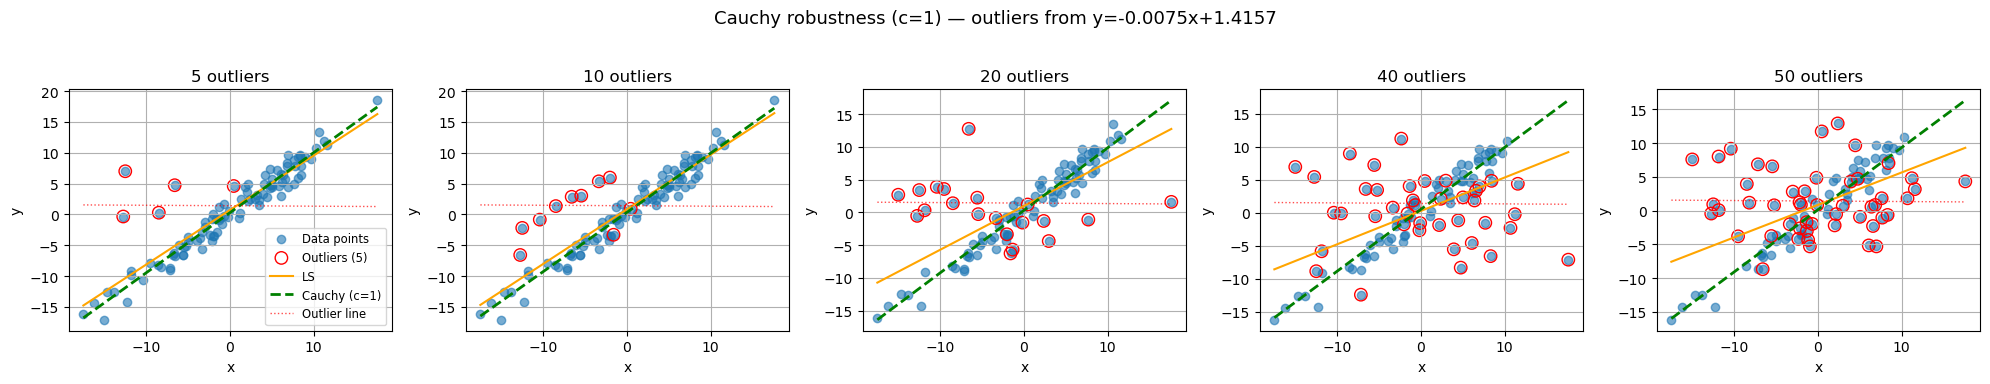

Cauchy parameter c = 0.01
Outliers= 5 | LS: w0=0.8776, w1=0.7377, RMSE_inliers=1.700
                 Cauchy(c=0.01): w0=0.0042, w1=0.0039, RMSE_inliers=7.139
Outliers=10 | LS: w0=0.8672, w1=0.7634, RMSE_inliers=1.745
                 Cauchy(c=0.01): w0=0.0098, w1=-0.0003, RMSE_inliers=7.175
Outliers=20 | LS: w0=0.6669, w1=0.8820, RMSE_inliers=2.616
                 Cauchy(c=0.01): w0=0.0066, w1=0.0018, RMSE_inliers=6.892
Outliers=40 | LS: w0=0.4812, w1=0.4634, RMSE_inliers=3.799
                 Cauchy(c=0.01): w0=-0.0147, w1=0.0014, RMSE_inliers=7.114
Outliers=50 | LS: w0=0.4326, w1=0.8047, RMSE_inliers=4.253
                 Cauchy(c=0.01): w0=0.0013, w1=0.0017, RMSE_inliers=7.213


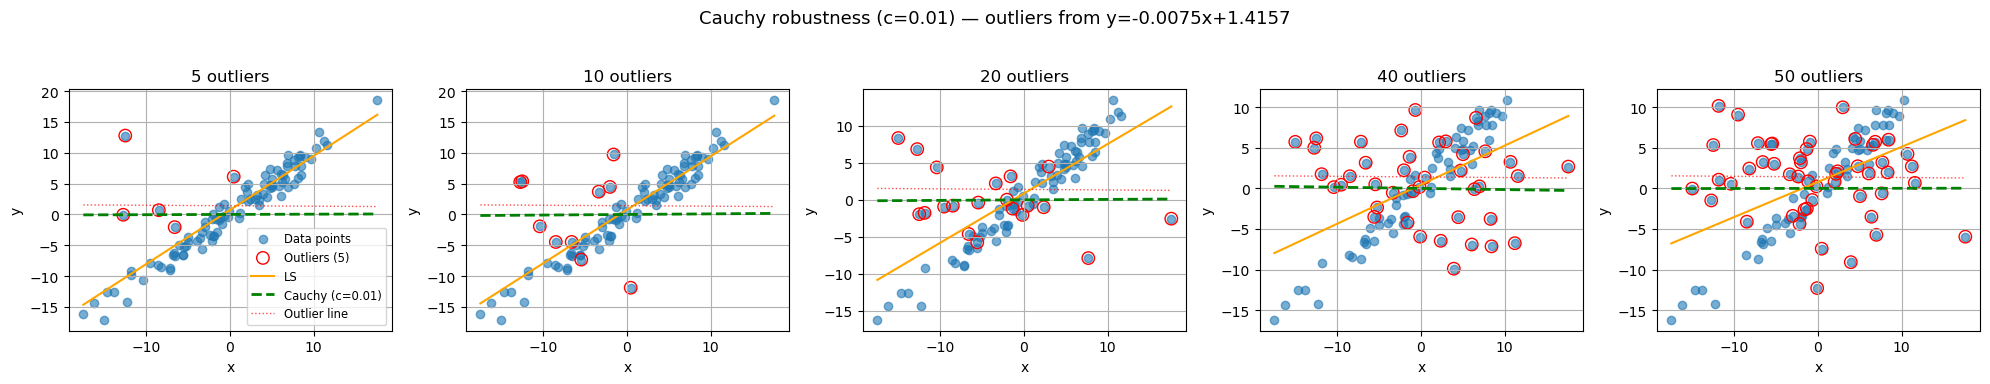


✅ Experiment finished.


In [13]:
###  EX 6 TYPE OF NOISE 3 ###

import numpy as np
import matplotlib.pyplot as plt

def run_cauchy_outlier_experiment_v2(
    outlier_counts=(5, 10, 20, 40, 50), 
    c_values=(1, 1/100),
    w0_outlier=-0.0075,
    w1_outlier=1.4157,
    outlier_sigma=5,
    seed=0
):
    """
    Test robustness of the Cauchy estimator by adding outliers generated from a different line.
    Inliers come from the original generate_points(angle_deg=45, seed=0) dataset.
    Outliers are generated according to y = w0_outlier * x + w1_outlier + noise.
    """
    np.random.seed(seed)

    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))

    # === Load base clean dataset (45° line, small noise) ===
    base_points = generate_points(angle_deg=45, seed=seed)
    n_total = len(base_points)

    # === Compute LS baseline on clean data ===
    w_ls_clean, b_ls_clean = gradient_descent(base_points, return_residuals=False)
    print(f"Baseline (clean) LS: w0={w_ls_clean:.4f}, w1={b_ls_clean:.4f}\n")

    # === Iterate over c values ===
    for c in c_values:
        print("===========================================")
        print(f"Cauchy parameter c = {c}")
        print("===========================================")

        n_cases = len(outlier_counts)
        fig, axes = plt.subplots(1, n_cases, figsize=(4 * n_cases, 4), squeeze=False)

        for idx, n_outliers in enumerate(outlier_counts):
            # Copy clean dataset
            points = base_points.copy()

            # Choose first n_outliers as outliers (or random subset)
            outlier_idx = np.arange(min(n_outliers, n_total))

            # Replace those y-values with points generated from the "outlier line"
            x_outliers = points[outlier_idx, 0]
            y_outliers = w0_outlier * x_outliers + w1_outlier + np.random.normal(0, outlier_sigma, len(x_outliers))
            points[outlier_idx, 1] = y_outliers

            # Fit both regressions
            w_ls, b_ls, u_ls = gradient_descent(points, return_residuals=True)
            w_c, b_c, u_c = gradient_descent_robust(points, c=c, return_residuals=True)

            # Compute RMSEs
            x = points[:, 0]
            y = points[:, 1]
            ypred_ls = w_ls * x + b_ls
            ypred_c = w_c * x + b_c
            rmse_all_ls = rmse(y, ypred_ls)
            rmse_all_c = rmse(y, ypred_c)

            # Compute inlier-only RMSE
            inlier_mask = np.ones(len(points), dtype=bool)
            inlier_mask[outlier_idx] = False
            rmse_inliers_ls = rmse(y[inlier_mask], ypred_ls[inlier_mask])
            rmse_inliers_c = rmse(y[inlier_mask], ypred_c[inlier_mask])

            # Print summary
            print(f"Outliers={n_outliers:2d} | LS: w0={w_ls:.4f}, w1={b_ls:.4f}, RMSE_inliers={rmse_inliers_ls:.3f}")
            print(f"                 Cauchy(c={c}): w0={w_c:.4f}, w1={b_c:.4f}, RMSE_inliers={rmse_inliers_c:.3f}")

            # === Plot ===
            ax = axes[0, idx]
            ax.scatter(x, y, color='tab:blue', alpha=0.6, label='Data points')
            if n_outliers > 0:
                ax.scatter(points[outlier_idx, 0], points[outlier_idx, 1],
                           facecolors='none', edgecolors='red', s=80, label=f'Outliers ({n_outliers})')

            sort_idx = np.argsort(x)
            x_sorted = x[sort_idx]
            ax.plot(x_sorted, w_ls * x_sorted + b_ls, color='orange', lw=1.5, label='LS')
            ax.plot(x_sorted, w_c * x_sorted + b_c, color='green', lw=2, ls='--', label=f'Cauchy (c={c})')

            # Add reference outlier line
            ax.plot(x_sorted, w0_outlier * x_sorted + w1_outlier, color='red', lw=1, ls=':', alpha=0.7, label='Outlier line')

            ax.set_title(f"{n_outliers} outliers")
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.grid(True)
            if idx == 0:
                ax.legend(fontsize='small')

        plt.suptitle(f"Cauchy robustness (c={c}) — outliers from y={w0_outlier}x+{w1_outlier}", fontsize=13)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    print("\n✅ Experiment finished.")


# Run the experiment
run_cauchy_outlier_experiment_v2()
